In [1]:
import pandas as pd 
from matplotlib import pyplot as plt 
import seaborn as sbn
import numpy as np
import statsmodels.api as sm

In [2]:
expr = pd.read_csv('~/local/data/ccle/OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv')
expr.head() 

,Unnamed: 0,SequencingID,ModelID,IsDefaultEntryForModel,ModelConditionID,IsDefaultEntryForMC,TSPAN6 (7105),TNMD (64102),DPM1 (8813),SCYL3 (57147),...,ATXN8 (724066),SMIM42 (117981789),NPBWR1 (2831),ACTL10 (170487),RNF228 (122319436),PANO1 (101927423),HRURF (120766137),PRRC2B (84726),F8A2 (474383),F8A1 (8263)
0,0,CDS-010xbm,ACH-001113,Yes,MC-001113-k2lR,Yes,4.956577,0.000000,7.577648,3.179411,...,0.0,0.0,0.414727,0.077634,1.113094,0.411901,0.0,5.134808,1.214541,4.315653
1,1,CDS-02TzJp,ACH-001289,Yes,MC-001289-BpdI,Yes,4.954992,0.617243,7.334747,2.783576,...,0.0,0.0,0.029840,0.000000,1.262156,1.026871,0.0,5.951231,0.007227,4.251060
2,2,CDS-0693hw,ACH-001339,Yes,MC-001339-5nRN,Yes,3.421952,0.000000,7.546069,2.615880,...,0.0,0.0,0.127768,0.105594,0.413829,0.540575,0.0,4.205971,0.030894,2.783448
3,3,CDS-07Plat,ACH-001619,No,MC-001619-IR6I,No,5.196729,0.000000,6.362268,2.144996,...,0.0,0.0,0.075396,0.932918,0.000000,0.511978,0.0,4.510747,3.223597,5.106595
4,4,CDS-08FOcu,ACH-001979,Yes,MC-001979-E3qW,Yes,4.651643,0.000000,5.946408,2.454515,...,0.0,0.0,0.012012,0.000000,1.006470,0.729221,0.0,4.922916,0.150926,4.661556


In [3]:
expr.columns[expr.columns.str.contains('DUSP6')]


Index(['DUSP6 (1848)'], dtype='object')

In [4]:
target_mirna = 'DUSP6 (1848)' #'FOXO3B (2310)' #'SMAD4 (4089)' #'TAL1 (6886)' #'ETV1 (2115)' #  'ETS1 (2113)' #'FOXO3 (2309)' # FOXO3B (2310)
target_drug = 'BRD-K12343256'

expr = expr.rename(columns={'ModelID': 'DepMap_ID'})
cell_info = pd.read_csv('~/local/data/ccle_info.txt', sep=',')[['DepMap_ID', 'CCLE_Name', 'lineage', 'primary_disease', 'Subtype']].dropna()
expr = expr.merge(cell_info, left_on='DepMap_ID', right_on='DepMap_ID', how='left')
expr = expr.set_index('DepMap_ID')
expr.head() 

,Unnamed: 0,SequencingID,IsDefaultEntryForModel,ModelConditionID,IsDefaultEntryForMC,TSPAN6 (7105),TNMD (64102),DPM1 (8813),SCYL3 (57147),FIRRM (55732),...,RNF228 (122319436),PANO1 (101927423),HRURF (120766137),PRRC2B (84726),F8A2 (474383),F8A1 (8263),CCLE_Name,lineage,primary_disease,Subtype
DepMap_ID,,,,,,,,,,,,,,,,,,,,,
ACH-001113,0,CDS-010xbm,Yes,MC-001113-k2lR,Yes,4.956577,0.000000,7.577648,3.179411,4.765742,...,1.113094,0.411901,0.0,5.134808,1.214541,4.315653,LC1SQSF_LUNG,lung,Lung Cancer,"Non-Small Cell Lung Cancer (NSCLC), Squamous C..."
ACH-001289,1,CDS-02TzJp,Yes,MC-001289-BpdI,Yes,4.954992,0.617243,7.334747,2.783576,3.736280,...,1.262156,1.026871,0.0,5.951231,0.007227,4.251060,COGAR359_SOFT_TISSUE,soft_tissue,Rhabdoid,Atypical Teratoid Rhabdoid Tumor (ATRT)
ACH-001339,2,CDS-0693hw,Yes,MC-001339-5nRN,Yes,3.421952,0.000000,7.546069,2.615880,4.476233,...,0.413829,0.540575,0.0,4.205971,0.030894,2.783448,COLO794_SKIN,skin,Skin Cancer,Melanoma
ACH-001619,3,CDS-07Plat,No,MC-001619-IR6I,No,5.196729,0.000000,6.362268,2.144996,3.087183,...,0.000000,0.511978,0.0,4.510747,3.223597,5.106595,OCUG1_BILIARY_TRACT,bile_duct,Gallbladder Cancer,Adenocarcinoma
ACH-001979,4,CDS-08FOcu,Yes,MC-001979-E3qW,Yes,4.651643,0.000000,5.946408,2.454515,1.852111,...,1.006470,0.729221,0.0,4.922916,0.150926,4.661556,NaN,NaN,NaN,NaN


In [6]:
expr.reset_index()[['DepMap_ID', 'primary_disease', 'Subtype']].drop_duplicates().groupby('primary_disease').count().loc['Breast Cancer']

DepMap_ID    62
Subtype      62
Name: Breast Cancer, dtype: int64

In [7]:
resp = pd.read_csv('~/local/data/ccle/sanger-dose-response.csv')
resp = resp[lambda x: x.BROAD_ID == target_drug]
resp.head() 

,DATASET,COSMIC_ID,DRUG_ID,MIN_CONC,MAX_CONC,RMSE_PUBLISHED,Z_SCORE_PUBLISHED,IC50_PUBLISHED,AUC_PUBLISHED,ARXSPAN_ID,DRUG_NAME,BROAD_ID,upper_limit,ec50,slope,lower_limit,auc,log2.ic50,mse,R2
257171,GDSC1,683665,1372,0.003906,1.0,0.119773,0.800808,2.481571,0.957176,ACH-002270,TRAMETINIB,BRD-K12343256,1.256407,0.077573,-0.052521,0.522920,0.891740,NaN,0.000590,0.375831
257172,GDSC1,684052,1372,0.003906,1.0,0.249754,0.423259,0.907994,0.883520,ACH-000052,TRAMETINIB,BRD-K12343256,1.095369,0.251481,-0.071063,0.388402,0.759300,NaN,0.001246,0.319947
257173,GDSC1,684055,1372,0.003906,1.0,0.079643,0.759437,2.222696,0.932690,ACH-002104,TRAMETINIB,BRD-K12343256,0.988113,0.179408,-1.159792,0.787311,0.922274,NaN,0.001470,0.781707
257174,GDSC1,684057,1372,0.003906,1.0,0.036387,1.308943,9.602803,0.968449,ACH-002106,TRAMETINIB,BRD-K12343256,1.046024,0.188491,-0.131159,0.888291,0.972795,NaN,0.000075,0.565207
257175,GDSC1,684059,1372,0.003906,1.0,0.063823,0.741538,2.119239,0.923213,ACH-002108,TRAMETINIB,BRD-K12343256,1.278697,0.376466,-0.129156,0.441299,0.907830,NaN,0.002214,0.552942


In [8]:
df = expr.merge(resp, left_on='DepMap_ID', right_on='ARXSPAN_ID', how='left')
df = df.assign(zscore_expr=lambda x: (x[target_mirna] - x[target_mirna].mean()) / x[target_mirna].std())
df = df.assign(zscore_auc=lambda x: (x.auc - x.auc.mean()) / x.auc.std())
df.head() 

,Unnamed: 0,SequencingID,IsDefaultEntryForModel,ModelConditionID,IsDefaultEntryForMC,TSPAN6 (7105),TNMD (64102),DPM1 (8813),SCYL3 (57147),FIRRM (55732),...,upper_limit,ec50,slope,lower_limit,auc,log2.ic50,mse,R2,zscore_expr,zscore_auc
0,0,CDS-010xbm,Yes,MC-001113-k2lR,Yes,4.956577,0.000000,7.577648,3.179411,4.765742,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.107088,NaN
1,1,CDS-02TzJp,Yes,MC-001289-BpdI,Yes,4.954992,0.617243,7.334747,2.783576,3.736280,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.344227,NaN
2,2,CDS-0693hw,Yes,MC-001339-5nRN,Yes,3.421952,0.000000,7.546069,2.615880,4.476233,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.198752,NaN
3,3,CDS-07Plat,No,MC-001619-IR6I,No,5.196729,0.000000,6.362268,2.144996,3.087183,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.544560,NaN
4,4,CDS-08FOcu,Yes,MC-001979-E3qW,Yes,4.651643,0.000000,5.946408,2.454515,1.852111,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.301678,NaN


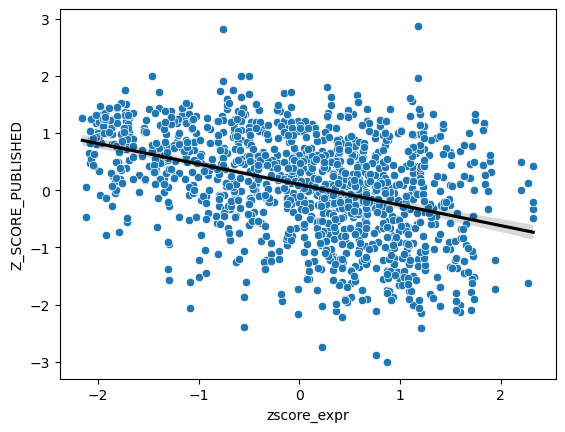

In [ ]:
# ALL cancers 

plt.figure() 
sbn.scatterplot(x='zscore_expr', y='Z_SCORE_PUBLISHED', data=df) 
sbn.regplot(x='zscore_expr', y='Z_SCORE_PUBLISHED', data=df, scatter=False, color='black')
plt.show() 

In [10]:
df__ = df[lambda x: x.CCLE_Name.str.contains('MCF7') \
    | x.CCLE_Name.str.contains('BT20') \
        | x.CCLE_Name.str.contains('MDAMB231') \
            | x.CCLE_Name.str.contains('T47D')][['DATASET', 'CCLE_Name', 'Z_SCORE_PUBLISHED', 'auc', 'zscore_expr', target_mirna]]

df__.style.hide()

DATASET,CCLE_Name,Z_SCORE_PUBLISHED,auc,zscore_expr,DUSP6 (1848)
GDSC1,MCF7_BREAST,1.311511,0.976778,-1.736573,0.925032
GDSC2,MCF7_BREAST,1.761750,nan,-1.736573,0.925032
GDSC1,MDAMB231_BREAST,-0.586737,0.603333,1.307126,7.350665
GDSC2,MDAMB231_BREAST,-0.472021,0.745774,1.307126,7.350665
GDSC1,MCF7_BREAST,1.311511,0.976778,-1.736727,0.924706
GDSC2,MCF7_BREAST,1.761750,nan,-1.736727,0.924706
GDSC1,T47D_BREAST,1.176727,0.937388,-1.123745,2.218790
GDSC2,T47D_BREAST,1.530974,0.933038,-1.123745,2.218790
GDSC1,BT20_BREAST,0.180402,0.755402,-1.530455,1.360173
GDSC2,BT20_BREAST,0.194446,0.854801,-1.530455,1.360173


In [11]:
df.head() 

,Unnamed: 0,SequencingID,IsDefaultEntryForModel,ModelConditionID,IsDefaultEntryForMC,TSPAN6 (7105),TNMD (64102),DPM1 (8813),SCYL3 (57147),FIRRM (55732),...,upper_limit,ec50,slope,lower_limit,auc,log2.ic50,mse,R2,zscore_expr,zscore_auc
0,0,CDS-010xbm,Yes,MC-001113-k2lR,Yes,4.956577,0.000000,7.577648,3.179411,4.765742,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.107088,NaN
1,1,CDS-02TzJp,Yes,MC-001289-BpdI,Yes,4.954992,0.617243,7.334747,2.783576,3.736280,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.344227,NaN
2,2,CDS-0693hw,Yes,MC-001339-5nRN,Yes,3.421952,0.000000,7.546069,2.615880,4.476233,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.198752,NaN
3,3,CDS-07Plat,No,MC-001619-IR6I,No,5.196729,0.000000,6.362268,2.144996,3.087183,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.544560,NaN
4,4,CDS-08FOcu,Yes,MC-001979-E3qW,Yes,4.651643,0.000000,5.946408,2.454515,1.852111,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.301678,NaN


/tmp/ipykernel_31579/170729498.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pval = reg.pvalues[1]


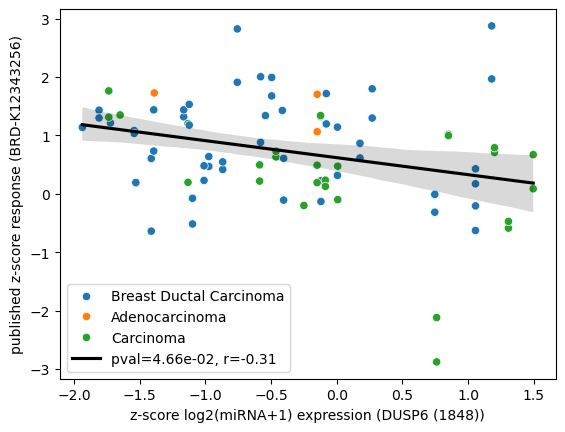

In [12]:
target_resp = 'Z_SCORE_PUBLISHED' 
target_expr = 'zscore_expr'
target_dataset = 'GDSC1'

df_breast = df[lambda x: (x.primary_disease == 'Breast Cancer') & (x.DATASET == target_dataset)][[target_expr, target_resp]].dropna()

r_spearman = df_breast.corr(method='spearman').values[0, 1] 

reg = sm.OLS(df_breast[target_resp], sm.add_constant(df_breast[target_expr])).fit()
pval = reg.pvalues[1]


plt.figure() 
sbn.scatterplot(x=target_expr, y=target_resp, data=df[lambda x: x.primary_disease == 'Breast Cancer'], hue='Subtype') 
sbn.regplot(x=target_expr, y=target_resp, data=df[lambda x: x.primary_disease == 'Breast Cancer'], scatter=False, color='black', label=f'pval={pval:.2e}, r={r_spearman:.2f}')
plt.legend()
plt.xlabel(f'z-score log2(miRNA+1) expression ({target_mirna})')
plt.ylabel(f'published z-score response ({target_drug})')
plt.show() 

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

low vs. medium: Mann-Whitney-Wilcoxon test two-sided, P_val:3.918e-01 U_stat=1.760e+02
medium vs. high: Mann-Whitney-Wilcoxon test two-sided, P_val:5.109e-01 U_stat=8.200e+01
low vs. high: Mann-Whitney-Wilcoxon test two-sided, P_val:2.362e-01 U_stat=5.300e+01


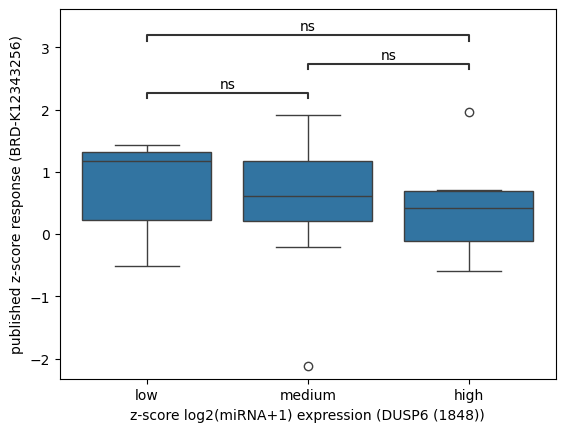

In [13]:
from statannotations.Annotator import Annotator

df_breast = df_breast.assign(expr_cat = lambda x: pd.cut(x[target_expr], bins=[-np.inf, -1, 1, np.inf], labels=['low', 'medium', 'high']))

plt.figure()
ax = sbn.boxplot(x='expr_cat', y=target_resp, data=df_breast)

plt.xlabel(f'z-score log2(miRNA+1) expression ({target_mirna})')
plt.ylabel(f'published z-score response ({target_drug})')

# Add significance annotations
pairs = [('low', 'medium'), ('medium', 'high'), ('low', 'high')]
annotator = Annotator(ax, pairs, data=df_breast, x='expr_cat', y=target_resp)
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
annotator.apply_and_annotate()

plt.show() 

# distribution of correlations 

In [14]:
expr = pd.read_csv('~/local/data/ccle/OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv')

expr = expr.rename(columns={'ModelID': 'DepMap_ID'})
cell_info = pd.read_csv('~/local/data/ccle_info.txt', sep=',')[['DepMap_ID', 'CCLE_Name', 'lineage', 'primary_disease', 'Subtype']].dropna()
expr = expr.merge(cell_info, left_on='DepMap_ID', right_on='DepMap_ID', how='left')
expr = expr.set_index('DepMap_ID')

expr[expr.columns[5:-4]] = expr[expr.columns[5:-4]].apply(lambda x: (x - x.mean()) / x.std())

resp = pd.read_csv('~/local/data/ccle/sanger-dose-response.csv')
resp = resp[lambda x: x.BROAD_ID == target_drug]

df = expr.merge(resp, left_on='DepMap_ID', right_on='ARXSPAN_ID', how='left')

df = df[lambda x: (x.primary_disease == 'Breast Cancer') & (x.DATASET == target_dataset)]


In [15]:
mrna_genes = expr.columns[5:-4].tolist() 

df2 = df[mrna_genes + ['Z_SCORE_PUBLISHED']]
corr_mat = df2.corr(method='spearman')

In [16]:
df2.head()

,TSPAN6 (7105),TNMD (64102),DPM1 (8813),SCYL3 (57147),FIRRM (55732),FGR (2268),CFH (3075),FUCA2 (2519),GCLC (2729),NFYA (4800),...,SMIM42 (117981789),NPBWR1 (2831),ACTL10 (170487),RNF228 (122319436),PANO1 (101927423),HRURF (120766137),PRRC2B (84726),F8A2 (474383),F8A1 (8263),Z_SCORE_PUBLISHED
36,0.025964,-0.184924,-0.870147,2.606829,0.040241,-0.350946,-0.975354,-0.242580,0.814368,-0.308075,...,-0.176023,-0.466388,0.418054,-0.452774,0.485490,-0.033758,0.051212,0.490344,-0.821658,1.966718
84,0.030948,-0.104819,1.788478,0.887770,0.016684,-0.343191,-0.967021,0.254761,0.665128,-0.191157,...,-0.176023,-0.451924,-0.948024,-0.503194,-0.373958,-0.033758,0.314574,0.452101,-0.111954,1.062881
103,0.272037,-0.184924,-0.802416,2.867278,0.594481,-0.310923,-0.892956,1.070378,0.572551,0.280241,...,-0.176023,-0.466388,2.621327,-0.549638,-0.150914,-0.033758,-0.229838,-0.705923,0.708643,-0.010455
118,0.332640,-0.184924,-0.168422,0.171909,0.702415,-0.287636,0.275190,0.692606,-0.236965,0.082651,...,-0.176023,3.894239,0.957868,-0.500540,1.287086,-0.033758,1.326406,0.025958,1.037985,0.880385
122,0.043574,-0.184924,0.164884,2.194128,-0.551825,-0.303490,-0.950820,-0.391063,0.440514,0.631258,...,-0.176023,-0.381424,0.447704,-0.470398,-0.024186,-0.033758,1.652498,-0.656863,0.611085,1.909326


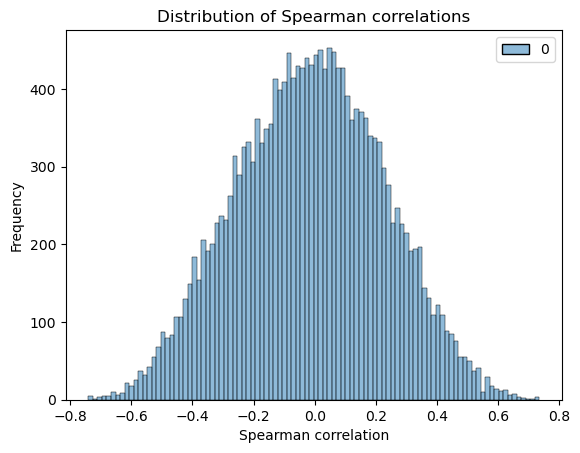

In [17]:
corrs_flat = corr_mat[['Z_SCORE_PUBLISHED']][lambda x: x.index != 'Z_SCORE_PUBLISHED'].values

plt.figure()
sbn.histplot(corrs_flat, bins=100)
plt.xlabel('Spearman correlation')
plt.ylabel('Frequency')
plt.title('Distribution of Spearman correlations')
plt.show()


In [18]:
(corrs_flat < -0.18).mean() 

np.float64(0.2545407233931824)

In [19]:
(corrs_flat < -0.48).mean() 

np.float64(0.024824355971896955)

In [20]:
(corrs_flat < -0.59).mean() 

np.float64(0.004475670049440541)

In [21]:
# DUSP6
(corrs_flat < -0.31).mean()

np.float64(0.11870934166016134)

In [20]:
max_corr = corrs_flat.max() 

In [21]:
corr_mat.iloc[(corr_mat.values == max_corr).nonzero()]

""
